In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('..') # Tells the notebook to look in the parent directory

from pipeline.spherex_contamination_analysis import spherex_contamination_analysis
from pipeline.image_contamination import plot_survey_comparison

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


/home/azupic/Projects/SPHEREx_pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [5]:
data = [
    {'source_id': 4012093916593061120, 'ra': 186.628469, 'dec': 30.647967, 'phot_g_mean_mag': 16.040756225585938},
    {'source_id': 1662622870104953472, 'ra': 205.250219, 'dec': 60.436094, 'phot_g_mean_mag': 16.777101516723633},
    {'source_id': 3108936854882971904, 'ra': 105.29821, 'dec': -2.431236, 'phot_g_mean_mag': 16.678071975708008},
    {'source_id': 5955233977135362816, 'ra': 264.817211, 'dec': -44.768268, 'phot_g_mean_mag': 18.968399047851562},
    {'source_id': 318381458887086976, 'ra': 25.99816, 'dec': 35.533183, 'phot_g_mean_mag': 17.98878288269043}
]

df = pd.DataFrame(data).astype({"source_id": "Int64"})

# Contamination analysis

This function sequentially passes the input catalog through a series of optical and near-infrared catalog filters (Gaia, DESI, Pan-STARRS, and SDSS), followed by a final image-level WCS PSF fitting filter. It is designed to identify and/or remove unresolved background contaminants that could blend into the large SPHEREx pixels.

Args:
- **df (pandas.DataFrame)**: The input catalog of targets. Must contain at least 'source_id', 'ra', and 'dec' columns. It is highly recommended to also include a 'phot_g_mean_mag' column (Gaia G-band magnitude), which is required for the image-level processing logic. If this column is missing, the function will automatically query the Gaia database to fetch the magnitude for each source.
- **search_radius_arcsec (float, optional)**: The radial distance in arcseconds to check for neighboring sources. Defaults to 9.3.
- **remove_contaminated (bool, optional)**: If True, drops rows from the DataFrame at each step if they are flagged as contaminated. This can speed up the execution significantly. If False, retains all rows and only appends the boolean flag columns (e.g., 'is_contaminated_gaia', 'note_gaia', etc.). Defaults to True. 
- **verbose (bool, optional)**: If True, prints progress and logging messages to the console. Defaults to False.

Returns:
- **pandas.DataFrame**: The processed DataFrame appended with contamination flags, investigation notes from each survey, and a final master 'is_contaminated' boolean column. If `remove_contaminated` is True, this returns only the isolated targets. If False, returns all the original targets.

In [6]:
result_df = spherex_contamination_analysis(df, 
                                           search_radius_arcsec=9.3, 
                                           remove_contaminated=False, 
                                           verbose=True)

------------------------------ Gaia DR3 Synchronous ADQL Check ------------------------------
Checking 5 candidates using Synchronous ADQL...

[1/5] 🟢 Source 4012093916593061120: Clean isolated target
[2/5] 🟢 Source 1662622870104953472: Clean isolated target
[3/5] 🔴 Flagging Source 3108936854882971904: Found 3 extra neighbor(s).
[4/5] 🔴 Flagging Source 5955233977135362816: Found 11 extra neighbor(s).
[5/5] 🟢 Source 318381458887086976: Clean isolated target

✅ Flagging complete!
Started with: 5 sources
Clean:        3 isolated sources
Flagged:      2 blended/error sources


-------------------------- DESI Legacy DR10 Tractor Catalog Check --------------------------
Checking 5 candidates against DESI DR10 Tractor (checking 9.3" around target)...

-> Filtering out noise artifacts with Signal-to-Noise Ratio (SNR) < 11.0
-> Ignoring ultra-close de-blending artifacts at distance < 1.0"
[1/5] 🟢 Source 4012093916593061120: Clean. (Target SNR_z: 2119.1)
[2/5] 🟢 Source 1662622870104953472: Clean

In [4]:
result_df

,source_id,ra,dec,phot_g_mean_mag,is_contaminated_gaia,note_gaia,is_contaminated_desi,note_desi,is_contaminated_panstarrs,note_panstarrs,...,note_unwise,is_contaminated_vhs,note_vhs,is_contaminated_des,note_des,is_contaminated_ukidss,note_ukidss,is_contaminated_image,note_image,is_contaminated
0,4012093916593061120,186.628469,30.647967,16.040756,False,Found 0 extra neighbor(s).,False,🟢 Source 4012093916593061120: Clean. (Target S...,False,🟢 Source 4012093916593061120: Clean. (Target S...,...,🟢 Source 4012093916593061120: Clean. (Target S...,False,⚠️ Source 4012093916593061120: No data found (...,False,⚠️ Source 4012093916593061120: No data found (...,False,⚠️ Source 4012093916593061120: No data found (...,False,🟢 Source 4012093916593061120: Clean isolated t...,False
1,1662622870104953472,205.250219,60.436094,16.777102,False,Found 0 extra neighbor(s).,False,🟢 Source 1662622870104953472: Clean. (Target S...,False,🟢 Source 1662622870104953472: Clean. (Target S...,...,🟢 Source 1662622870104953472: Clean. (Target S...,False,⚠️ Source 1662622870104953472: No data found (...,False,⚠️ Source 1662622870104953472: No data found (...,False,⚠️ Source 1662622870104953472: No data found (...,True,🔴 Source 1662622870104953472: 1 contaminants f...,True
2,3108936854882971904,105.298210,-2.431236,16.678072,True,Found 3 extra neighbor(s).,False,⚠️ Source 3108936854882971904: No data found (...,True,🔴 Flagging Source 3108936854882971904: 3 PS1 n...,...,🔴 Flagging Source 3108936854882971904: 2 unWIS...,False,⚠️ Source 3108936854882971904: No data found (...,False,⚠️ Source 3108936854882971904: No data found (...,False,⚠️ Source 3108936854882971904: No data found (...,True,🔴 Source 3108936854882971904: 4 contaminants f...,True
3,5955233977135362816,264.817211,-44.768268,18.968399,True,Found 11 extra neighbor(s).,False,⚠️ Source 5955233977135362816: No data found (...,False,⚠️ Source 5955233977135362816: No data found (...,...,🔴 Flagging Source 5955233977135362816: 2 unWIS...,True,🔴 Flagging Source 5955233977135362816: 3 VHS n...,False,⚠️ Source 5955233977135362816: No data found (...,False,⚠️ Source 5955233977135362816: No data found (...,True,🔴 Source 5955233977135362816: Target missing f...,True
4,318381458887086976,25.998160,35.533183,17.988783,False,Found 0 extra neighbor(s).,False,⚠️ Source 318381458887086976: No data found (l...,False,🟢 Source 318381458887086976: Clean. (Target SN...,...,🟢 Source 318381458887086976: Clean. (Target SN...,False,⚠️ Source 318381458887086976: No data found (l...,False,⚠️ Source 318381458887086976: No data found (l...,False,⚠️ Source 318381458887086976: No data found (l...,False,🟢 Source 318381458887086976: Clean isolated ta...,False


# Plot Survey Comparison

This function utilizes a fallback hierarchy to fetch the two highest-quality available images for a given coordinate (e.g., trying DESI Legacy first, then PanSTARRS, SDSS, and DSS2). It applies World Coordinate System (WCS) astrometry to pinpoint the theoretical target location, detects observed sources using DAOStarFinder, and visualizes potential contamination by drawing dynamic Point Spread Function (PSF) wings based on each survey's optical properties. 

To ensure high accuracy, the function implements a magnitude-dependent artifact filtering strategy: it automatically skips detection for heavily saturated bright stars (G < 13) to avoid "shredding" artifacts, and applies dynamic saddle-point deblending (profile checking) to distinguish real faint companions from artificial halo shine on fainter targets.

Args:
- **source_id (int or str)**: The unique identifier for the target (used for the plot title).
- **ra (float)**: Right Ascension of the target in degrees (ICRS).
- **dec (float)**: Declination of the target in degrees (ICRS).
- **g_mag (float, optional)**: The Gaia G-band mean magnitude of the target. This value dictates the sensitivity of the artifact filter and whether image fitting is bypassed entirely. If not provided (`None`), the function will automatically query the Gaia database to fetch it prior to plotting.
- **fov_arcsec (float, optional)**: The field of view for the downloaded FITS cutouts in arcseconds. Defaults to 30.
- **search_radius_arcsec (float, optional)**: The radial distance in arcseconds to check for neighboring sources. Defaults to 9.3.
- **wing_multiplier (float, optional)**: A tuning parameter that scales the calculated physical extent of the PSF wings. A value > 1.0 makes the contamination check more conservative/aggressive. Defaults to 1.0.

Returns:
- **None**: This function does not return any variables. It directly displays a matplotlib figure showing the two image panels with overlaid astrometric and contamination diagnostics.

### Example of contaminated


Fetching images for Source 3108936854882971904 (ra=105.29821, dec=-2.43124)
  Slot 1:
    Trying Legacy … ✗ (no data / no coverage)
    Trying PanSTARRS … ✓ (y-band)
  Slot 2:
    Skipping PanSTARRS (Already showing in other slot)
    Trying DES … ✗ (no data / no coverage)
    Trying VHS … ✗ (no data / no coverage)
    Trying UKIDSS … ✗ (no data / no coverage)
    Trying SDSS … ✗ (no data / no coverage)
    Trying DSS2 … ✓ (NIR-band)


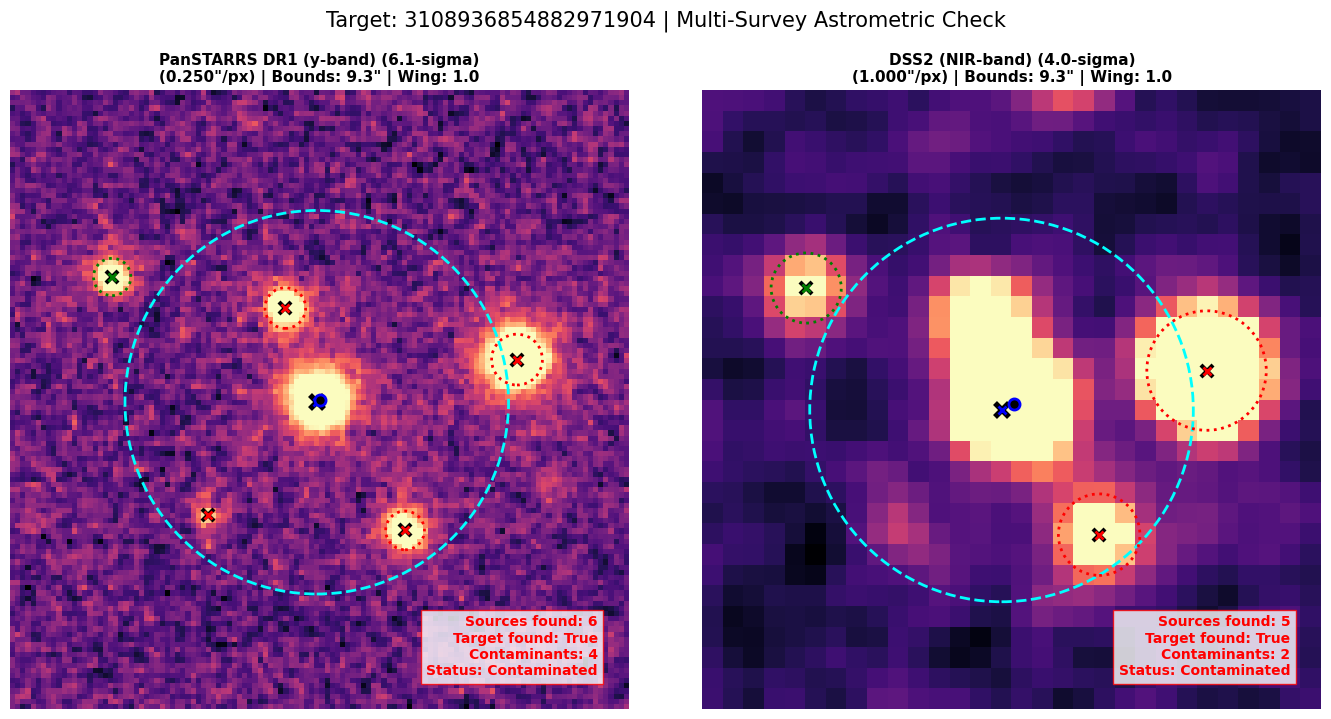

In [2]:
plot_survey_comparison(source_id=3108936854882971904, 
                       ra=105.29821, 
                       dec=-2.431236, 
                       g_mag=16.6781,
                       search_radius_arcsec=9.3)

### Example of uncontaminated


Fetching images for Source 4012093916593061120 (ra=186.62847, dec=30.64797)
  Slot 1:
    Trying Legacy … ✓ (z-band)
  Slot 2:
    Trying PanSTARRS … ✓ (y-band)


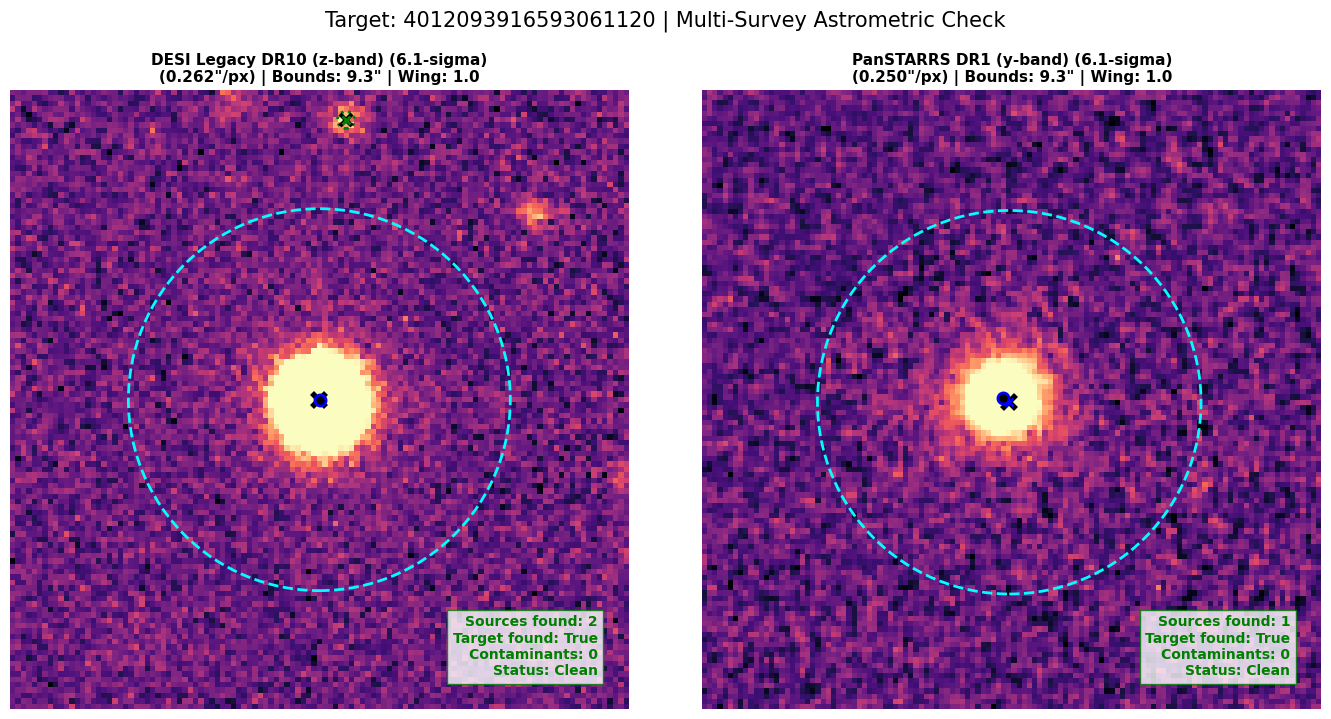

In [3]:
plot_survey_comparison(source_id=4012093916593061120, 
                       ra=186.628469, 
                       dec=30.647967, 
                       g_mag=16.0408,
                       search_radius_arcsec=9.3)